# Importación de librerías

In [1]:
# Librerías visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías manipulación de datos
import numpy as np
import pandas as pd

# Importación de datos

In [2]:
# Importación de datos
df = pd.read_csv('MSD-MEDIO_AAA_Cu_Fe_Au_Co_S.csv')

In [3]:
df.head(3)

,SAMPLE_ID,Inserto,Cu,Fe,Au,Co,S,Origen
0,STD MEDIUM 1,1,0.451,30.77,0.094,190,1.53,P2022-111 Análisis Estandares MSDv3.xlsx
1,STD MEDIUM 2,2,0.466,31.66,0.102,190,1.50,P2022-111 Análisis Estandares MSDv3.xlsx
2,STD MEDIUM 3,3,0.452,30.94,0.080,200,1.53,P2022-111 Análisis Estandares MSDv3.xlsx


In [4]:
df.shape

(30, 8)

# Gráfico de Exactitud

In [5]:
# Ejes para gráfico de control de exactitud
x = df['Inserto']
y = df['Cu']

In [6]:
# Editar analito, laboratorio y CRM 
analito = 'Cu'
lab = 'AAA Chile'
crm = 'MEDIO'

In [7]:
# Media y desviación estándar del CRM
av = 0.472
desvest = 0.01580

In [8]:
# Bandas de aceptación
minus2SD = av - 2 * desvest
minus3SD = av - 3 * desvest
plus2SD = av + 2 * desvest
plus3SD = av + 3 * desvest

In [9]:
# Chequeo
minus3SD

0.4246

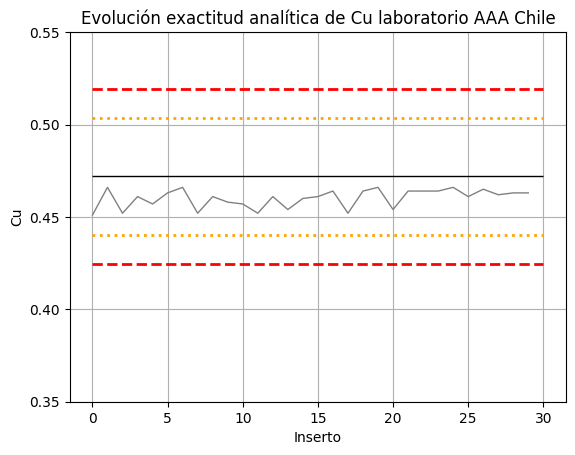

In [10]:
fig,ax = plt.subplots()

ax.set_title("Evolución exactitud analítica de {} laboratorio {}".format(analito,lab))

# lineplot de insertos 
ax.plot(y, color='grey', linewidth=1)

# lineplot edgecolors para warnings y error
for i in range(len(y)):
    if y[i] < minus3SD or y[i] > plus3SD:
        ax.scatter(x[i],y[i], edgecolors='red', color='white')
    elif y[i] < minus2SD or y[i] > plus2SD:
        ax.scatter(x[i],y[i], edgecolors='orange', color='white')    
    else:
        ax.scatter(x[i],y[i], color='white')     
    
# Líneas de control    
ax.hlines(y=av, xmin=0, xmax=len(df), linewidth=1, color='black', linestyles='-')
ax.hlines(y=minus2SD, xmin=0, xmax=len(df), linewidth=2, color='orange', linestyles=':')
ax.hlines(y=plus2SD, xmin=0, xmax=len(df), linewidth=2, color='orange', linestyles=':')
ax.hlines(y=minus3SD, xmin=0, xmax=len(df), linewidth=2, color='red', linestyles='--')
ax.hlines(y=plus3SD, xmin=0, xmax=len(df), linewidth=2, color='red', linestyles='--')

# Editar rango eje Y (ley) y frecuencia de tick marks
plt.ylim([0.35,0.55])
plt.yticks(np.arange(0.35,0.55,.05))

# Grilla
plt.grid()

# Títulos de ejes
plt.xlabel('Inserto')
plt.ylabel(analito);

**Comentarios:**
- No se identifican resultados con fallas 
- Sin exceso de puntos consecutivos por sobre o debajo de valor esperado: ausencia de sesgo moderado
- Ausencia de puntos consecutivos sobre 2 STD            

# Cálculo de sesgo

In [11]:
# Valor medio análisis de CRM
prom = df['Cu'].mean()
prom

0.4601333333333333

In [12]:
# Cálculo de sesgo
sesgo = (prom - av) / av * 100

In [14]:
print("Sesgo de {} para CRM {} en laboratorio {} es {:.2f}".format(analito,crm,lab,sesgo))

Sesgo de Cu para CRM MEDIO en laboratorio AAA Chile es -2.51


**Conclusión:**
- Sin evidencia de sesgo significativo a nivel global (todas las campañas).